# Dwelling Classifier Pipeline
## New workflow (feature_store + FeatureSetConfig)

**Step 1** — Run `build_full_cache()` ONCE (or when raw data changes).  
**Step 2** — Run `update_cache()` ONLY when you add new features to the logic file.  
**Step 3** — Declare a `FeatureSetConfig` for each experiment.  
**Step 4** — `train → infer → predict → assess` using that config.  

The cache is **annotation-free and split-ignorant** — it stores every feature
for every frame of every source.  Labels and train/val splits are applied
inside `train()` and `infer()` by joining `ctx.annotated` at run-time.

In [1]:
# ── CELL 0  Imports & paths ───────────────────────────────────────────────────
import importlib
import random
import os
import gc
import shutil
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd

import feature_store as fs
importlib.reload(fs)
import tp_export as tp
from tp_export import PostProcessConfig
import split_dataset as sd
from pp import get_context, validate_context

# ── Paths (edit to match) ─────────────────────────────────
TRAIN_DATA   = Path(r"C:\Users\corna\honours\fresh1\hp_2\notebooks\parquet_pipeline\annotations_split\train")
ANN_MASTER   = Path(r"C:\Users\corna\honours\fresh1\hp_2\data_intermediate\annotation\annotation.csv")
BASE_OUT_DIR = Path(r"C:\Users\corna\honours\fresh1\hp_2\data_intermediate\exported_models")

# Master feature cache — shared across ALL experiments
# One parquet per source, no annotation data, never needs rebuilding unless
# raw trajectory data changes or you add new base features.
MASTER_CACHE_DIR = BASE_OUT_DIR / "master_feature_cache"

LOGIC_FILE = "feature_registry"
FPS        = 6.0

SESSION_DIR = TRAIN_DATA / "train"
VAL_DIR     = TRAIN_DATA / "validation"

In [2]:
# ── CELL 1  Split dataset ────────────────────────────────────
seed = random.randint(0, 4294967295)
importlib.reload(sd)
sd.split_dataset(TRAIN_DATA, TRAIN_DATA, mode="train", RANDOM_SEED=seed)

Loaded 2 CSV files
Total rows: 862

Tags used for balancing:
  alright              56
  arc                  26
  backtrack            11
  crawl                82
  double_turn          32
  long                 101
  long_run             22
  low_turn             30
  paused               6
  sharp_turn           33
  triple_turn          30
  unsure               26
  wide_turn            21
  wonderful            176

Locked train larvae: 0
Locked test larvae : 0
New larvae         : 350
Target new test larvae: 70


TypeError: Invalid value 'validation' for dtype 'float64'

In [ ]:
# ── CELL 2  Build context ────────────────────────────────────
train_ann = pd.read_csv(SESSION_DIR / "annotations_train.csv")
val_ann   = pd.read_csv(VAL_DIR     / "annotations_validation.csv")

TRAIN_PREFIXES = train_ann["source"].unique().tolist()
TEST_FILES     = val_ann["source"].unique().tolist()
sources        = list(set(TRAIN_PREFIXES).union(set(TEST_FILES)))

TRAIN_SLICES = {src: slice(None) for src in TRAIN_PREFIXES}
train_keys   = train_ann[["source", "ID"]].drop_duplicates()
val_keys     = val_ann[["source", "ID"]].drop_duplicates()

ctx = get_context(
    parquet_path = Path(r"C:\Users\corna\honours\fresh1\hp_2\data_intermediate\raw_trajectories.parquet"),
    ann_csv      = ANN_MASTER,
    session_dir  = TRAIN_DATA,
    sources      = sources,
)
clean_full_annotations = ctx.annotated.copy()

# Post-processing config
MF, TH, GC, GO = 5, 0.6, 4, 13

ppc    = PostProcessConfig(MF, TH, GC, GO)
ppc_id = ppc.get_IDstr()

print(f"Train sources : {TRAIN_PREFIXES}")
print(f"Val sources   : {TEST_FILES}")

Loading raw trajectories from parquet...
  → 16,859,236 framessources: ['EA', 'GA1', 'GA2', 'GA3', 'H2O']
Loading annotations...
  → 643 annotation intervals
      nondwelling: 344
      dwelling: 259
      turn: 20
      crawling: 20
Labelling frames...
  → 148,697 labeled frames
      nondwelling: 81,505 frames
      dwelling: 64,443 frames
      crawling: 2,178 frames
      turn: 571 frames
Train sources : ['GA1', 'GA3', 'GA2', 'EA', 'H2O']
Val sources   : ['GA1', 'GA3', 'GA2', 'EA', 'H2O']


---
## Step 1 — Build master feature cache (run once)

Computes **every feature** for **every frame** of **every source**.  
No annotations, no labels, no split awareness.  
Pass `force=True` to rebuild (e.g. after raw parquet changes).  
Pass `sources=[...]` to add only new sources to an existing cache.

In [6]:
# ── CELL 3  Build full cache (ONCE) ──────────────────────────────────────────
importlib.reload(fs)

fs.build_full_cache(
    ctx        = ctx,
    logic_file = LOGIC_FILE,
    cache_dir  = MASTER_CACHE_DIR,
    fps        = FPS,
    # sources  = ["H2O"],   # uncomment to add a single new source
    # force    = True,       # uncomment to force-recompute all sources
)

# Health check
fs.check_cache_health(MASTER_CACHE_DIR, ctx=ctx, logic_file=LOGIC_FILE)

[feature_store] Building cache for 5 sources → C:\Users\corna\honours\fresh1\hp_2\data_intermediate\exported_models\master_feature_cache
  [EA] calculating features …
Calculating base signals... (windows: [11, 30, 50, 75])
Calculating windowed features...
  Window 11s …
  Window 30s …
  Window 50s …
  Window 75s …
  [EA] → features_EA.parquet  (2,290,988 rows, 94 features)
  [GA1] calculating features …
Calculating base signals... (windows: [11, 30, 50, 75])
Calculating windowed features...
  Window 11s …
  Window 30s …
  Window 50s …
  Window 75s …
  [GA1] → features_GA1.parquet  (3,518,524 rows, 94 features)
  [GA2] calculating features …
Calculating base signals... (windows: [11, 30, 50, 75])
Calculating windowed features...
  Window 11s …
  Window 30s …
  Window 50s …
  Window 75s …
  [GA2] → features_GA2.parquet  (3,927,327 rows, 94 features)
  [GA3] calculating features …
Calculating base signals... (windows: [11, 30, 50, 75])
Calculating windowed features...
  Window 11s …
  Win

---
## Step 2 — Update cache (optional — only when logic file changes)

If you add a new feature to `exp_feature_calculation.py`.  
It appends only the new columns — never rewrites existing ones.

In [7]:
# ── CELL 4  Update cache with new features (OPTIONAL) ─────────────────────────
importlib.reload(fs)

# Option A — let the system auto-detect missing columns:
# fs.update_cache(ctx, LOGIC_FILE, MASTER_CACHE_DIR, fps=FPS)

# Option B — explicitly name the new columns you added:
# fs.update_cache(ctx, LOGIC_FILE, MASTER_CACHE_DIR, fps=FPS,
#                 new_columns=["w30_my_new_feature", "w75_my_new_feature"])

# Option C — bump version of a column whose formula changed:
# fs.update_cache(ctx, LOGIC_FILE, MASTER_CACHE_DIR, fps=FPS,
#                 version_bump={"w50_tortuosity": 2})

# Browse what's in the cache:
cached_features = fs.list_cached_features(MASTER_CACHE_DIR)
print(cached_features.to_string())

                        feature_name  version             added_at  window_size
0                  larva_body_length        1  2026-06-08T18:29:43          NaN
8                    w11_bending_std        1  2026-06-08T18:29:43         11.0
9                  w11_hc_ratio_mean        1  2026-06-08T18:29:43         11.0
10                 w11_ht_ratio_mean        1  2026-06-08T18:29:43         11.0
6                            w11_msd        1  2026-06-08T18:29:43         11.0
7                       w11_msd_norm        1  2026-06-08T18:29:43         11.0
1                w11_omega_body_mean        1  2026-06-08T18:29:43         11.0
11  w11_omega_body_mean_slope_smooth        1  2026-06-08T18:29:43         11.0
2                 w11_omega_head_std        1  2026-06-08T18:29:43         11.0
3            w11_omega_relative_mean        1  2026-06-08T18:29:43         11.0
4                            w11_rog        1  2026-06-08T18:29:43         11.0
5                     w11_tortuosity    

---
## Step 3 — Declare a FeatureSetConfig

This is the **only thing you change** between experiments.  
The config is saved alongside the model so you always know what went in.

In [4]:
# ── CELL 5  Define experiment feature set ─────────────────────────────────────

importlib.reload(fs)
from feature_store import FeatureSetConfig

# Example: full feature set (same as the original hard-coded set)
fsc = FeatureSetConfig(
    name="test",
    description="6 features",
    base_features=["larva_body_length"],
    windowed_features={
        # present at every window
        "omega_body_mean":     [11,20, 30, 50, 75],
        "omega_head_std":      [11, 30, 50, 75],
        "omega_relative_mean": [11, 30, 50, 75],
        "rog":                 [11, 30, 50, 75],
        "tortuosity":          [11, 30, 50, 75],
        "msd":                 [11, 30, 50, 75],
        # # w11 extras
        # "bending_std":              [11, 50, 75],
        # "hc_ratio_mean":            [11, 50, 75],
        # "ht_ratio_mean":            [11, 50, 75],
        # "omega_body_mean_slope_smooth": [11, 50, 75],
        # # w30+ extras
        # "vel_mean":            [30, 50, 75],
        # "vel_std":             [30, 50, 75],
        # "vel_norm_mean":       [30, 50, 75],
        # "head_vel_mean":       [30, 50, 75],
        # "head_vel_std":        [30, 50, 75],
        # "omega_heading_mean":  [30, 50, 75],
        # "coverage":            [30, 50, 75],
        # "bend_peaks_rate":     [30, 50, 75],
        # "pause_run_frac":      [30, 50, 75],
        # "reversal_rate":       [30, 50, 75],
        # "angular_tortuosity":  [30, 50, 75],
        # "revisitation_mean":   [30, 50, 75],
        # "revis_slope_smooth":  [30, 50, 75],
        # "rog_slope_smooth":    [30, 50, 75],
        # "tort_slope_smooth":   [30, 50, 75],
        # # w50+ extras
        # "vel_lag":             [50, 75],
        # "vel_lead":            [50, 75],
        # # w75 only
        # "bend_freq_rolling":   [75],
    },
)

# Example: ablation — velocity features only
# fsc = FeatureSetConfig(
#     name="velocity_only",
#     description="Ablation: only velocity-based features across all windows",
#     base_features=["larva_body_length"],
#     windowed_features={
#         "vel_mean":       [30, 50, 75],
#         "vel_std":        [30, 50, 75],
#         "head_vel_mean":  [30, 50, 75],
#         "head_vel_std":   [30, 50, 75],
#         "vel_lag":        [50, 75],
#         "vel_lead":       [50, 75],
#     },
# )

print(fsc.summary())

# Validate against the cache — auto-fills any missing columns
fsc.validate_against_cache(
    MASTER_CACHE_DIR,
    ctx=ctx,
    logic_file=LOGIC_FILE,
    fps=FPS,
    auto_fill=True,
)

FeatureSetConfig 'test'
  Description   : 6 features
  Base features : ['larva_body_length']
  Windowed      :
    omega_body_mean                windows=[11, 20, 30, 50, 75]
    omega_head_std                 windows=[11, 30, 50, 75]
    omega_relative_mean            windows=[11, 30, 50, 75]
    rog                            windows=[11, 30, 50, 75]
    tortuosity                     windows=[11, 30, 50, 75]
    msd                            windows=[11, 30, 50, 75]
  Total columns : 26
[FeatureSetConfig 'test'] ✓ All 26 columns present in cache.


[]

---
## Step 4 — Train → Infer → Predict → Assess

In [5]:
# ── CELL 6  Output paths ──────────────────────────────────────────────────────
importlib.reload(tp)
SEED = seed
try:
    SEED
except NameError:
    SEED = random.randint(0, 4294967295)

RUN_ID = datetime.now().strftime("%Y%m%d_%H%M%S")
prefixes = list(TRAIN_SLICES.keys())
train_str = "-".join(prefixes)

model_folder_name = (
    f"RUN_{LOGIC_FILE}_{fsc.name}_{RUN_ID}_train-{train_str}"
)
final_output_path = BASE_OUT_DIR / model_folder_name

model_path         = final_output_path / "final_model.pkl"
probabilities_path = final_output_path / "probabilities.csv"
predictions_dir    = final_output_path / "predictions"
feature_path       = final_output_path / "feature_set_config.pkl"   # stores FSC object
metadata_path      = final_output_path / "metadata.pkl"
metadata_test_path = final_output_path / "metadata_test.pkl"
plot_path          = final_output_path / "plots"
report_path        = final_output_path / "experiment_log.txt"

os.makedirs(predictions_dir, exist_ok=True)
os.makedirs(final_output_path, exist_ok=True)

with open(report_path, "a") as f:
    f.write(f"Session initialized at: {datetime.now()}\n")
    f.write(f"Logic file: {LOGIC_FILE}\n")
    f.write(f"Feature set: {fsc.name}\n")
    f.write(fsc.summary() + "\n\n")

print(f"Outputs → {final_output_path}")

Outputs → C:\Users\corna\honours\fresh1\hp_2\data_intermediate\exported_models\RUN_feature_registry_test_20260609_113618_train-GA1-GA3-GA2-EA-H2O


In [ ]:
# ── CELL 7  Train ─────────────────────────────────────────────────────────────
importlib.reload(tp)
#importlib.reload(fs)
#from feature_store import FeatureSetConfig

print("\n--- INITIATING TRAINING ---")
ctx.annotated = clean_full_annotations.copy()

model, features, metadata, log_messages = tp.train(
    ctx          = ctx,
    slices       = TRAIN_SLICES,
    prefixes     = prefixes,
    logic_file   = LOGIC_FILE,
    model_path   = model_path,
    feature_path = feature_path,
    metadata_path= metadata_path,
    seed         = SEED,
    cache_dir    = MASTER_CACHE_DIR,
    fsc          = fsc,
    train_keys   = train_keys,   # ← train() pre-filters annotations to these larvae
)


--- INITIATING TRAINING ---
[FeatureSetConfig 'test'] ✓ All 26 columns present in cache.

[train] FeatureSetConfig 'test': 26 features
[train] Loading from cache for sources: ['GA1', 'GA3', 'GA2', 'EA', 'H2O']


[train] Pre-filtering annotation table to train-split larvae …
[train] Annotations restricted: 148697 → 116072 rows (280 larvae)
[train] Training on 116,030 rows (52564 dwelling / 63466 nondwelling)
Model saved      → C:\Users\corna\honours\fresh1\hp_2\data_intermediate\exported_models\RUN_feature_registry_test_20260609_113618_train-GA1-GA3-GA2-EA-H2O\final_model.pkl
FSC saved        → C:\Users\corna\honours\fresh1\hp_2\data_intermediate\exported_models\RUN_feature_registry_test_20260609_113618_train-GA1-GA3-GA2-EA-H2O\feature_set_config.pkl
Metadata saved   → C:\Users\corna\honours\fresh1\hp_2\data_intermediate\exported_models\RUN_feature_registry_test_20260609_113618_train-GA1-GA3-GA2-EA-H2O\metadata.pkl
FSC (JSON) saved → C:\Users\corna\honours\fresh1\hp_2\data_intermediate\exported_models\RUN_feature_registry_test_20260609_113618_train-GA1-GA3-GA2-EA-H2O\feature_set_config.json


In [7]:
# ── CELL 8  Infer ─────────────────────────────────────────────────────────────
importlib.reload(tp)

ctx.annotated = clean_full_annotations.merge(val_keys, on=["source", "ID"], how="inner")

metadata_test, log_messages_inf = tp.infer(
    model_path         = model_path,
    ctx                = ctx,
    files              = TEST_FILES,
    feature_path       = feature_path,
    probabilities_path = probabilities_path,
    metadata_test_path = metadata_test_path,
    cache_dir          = MASTER_CACHE_DIR,
    logic_file         = LOGIC_FILE,
    fsc                = fsc,             )

Model loaded from C:\Users\corna\honours\fresh1\hp_2\data_intermediate\exported_models\RUN_feature_registry_test_20260609_113618_train-GA1-GA3-GA2-EA-H2O\final_model.pkl

[infer] FeatureSetConfig 'test': 26 features
[FeatureSetConfig 'test'] ✓ All 26 columns present in cache.

=== Processing file_id=GA1 ===
  Loading features from cache …
  Source: GA1  |  Rows: 3,518,524
  RAM free: 4.9 GB
  Matched 5634 annotated frames.
  Probabilities appended → C:\Users\corna\honours\fresh1\hp_2\data_intermediate\exported_models\RUN_feature_registry_test_20260609_113618_train-GA1-GA3-GA2-EA-H2O\probabilities.csv
  RAM free after cleanup: 8.5 GB

=== Processing file_id=GA3 ===
  Loading features from cache …
  Source: GA3  |  Rows: 3,903,910
  RAM free: 4.7 GB
  Matched 17358 annotated frames.
  Probabilities appended → C:\Users\corna\honours\fresh1\hp_2\data_intermediate\exported_models\RUN_feature_registry_test_20260609_113618_train-GA1-GA3-GA2-EA-H2O\probabilities.csv
  RAM free after cleanup: 8

In [8]:
# ── CELL 9  Predict (post-process) ────────────────────────────────────────────
importlib.reload(tp)

predictions = tp.predict(
    probabilities_path = probabilities_path,
    ppc                = ppc,
    predictions_dir    = predictions_dir,
    ctx                = ctx,
    logic_file         = LOGIC_FILE,
    plot               = False,
)

c:\Users\corna\honours\fresh1\hp_2\notebooks\parquet_pipeline\tp_export.py:383: DtypeWarning: Columns (0: behavior, 1: tags) have mixed types. Specify dtype option on import or set low_memory=False.
  df_probs = pd.read_csv(probabilities_path)


Predicting for EA track 0…
Predicting for EA track 1000…
Predicting for EA track 2000…
Predicting for EA track 3000…
Predicting for GA1 track 0…
Predicting for GA1 track 1000…
Predicting for GA1 track 2000…
Predicting for GA1 track 3000…
Predicting for GA1 track 4000…
Predicting for GA1 track 5000…
Predicting for GA1 track 6000…
Predicting for GA2 track 0…
Predicting for GA2 track 1000…
Predicting for GA2 track 2000…
Predicting for GA2 track 3000…
Predicting for GA2 track 4000…
Predicting for GA2 track 5000…
Predicting for GA2 track 6000…
Predicting for GA3 track 0…
Predicting for GA3 track 1000…
Predicting for GA3 track 2000…
Predicting for GA3 track 3000…
Predicting for GA3 track 4000…
Predicting for GA3 track 5000…
Predicting for GA3 track 6000…
Predicting for H2O track 0…
Predicting for H2O track 1000…
Predicting for H2O track 2000…
Predicting for H2O track 3000…
Predicting for H2O track 4000…
Predicting for H2O track 5000…
Saved post-processed predictions → C:\Users\corna\honours\

c:\Users\corna\honours\fresh1\hp_2\notebooks\parquet_pipeline\tp_export.py:561: DtypeWarning: Columns (0: behavior, 1: tags) have mixed types. Specify dtype option on import or set low_memory=False.
  results   = pd.read_csv(pred_path).copy()


[assess_performance] Val-key filter: 16859236 → 55911 rows (70 validation larvae)
[assess_performance] ✓ Contamination check passed — no train larvae in evaluation subset.


{'f1': 0.928498258553575,
 'precision': 0.8966267682263329,
 'recall/sensitivity': 0.9627190653212958}

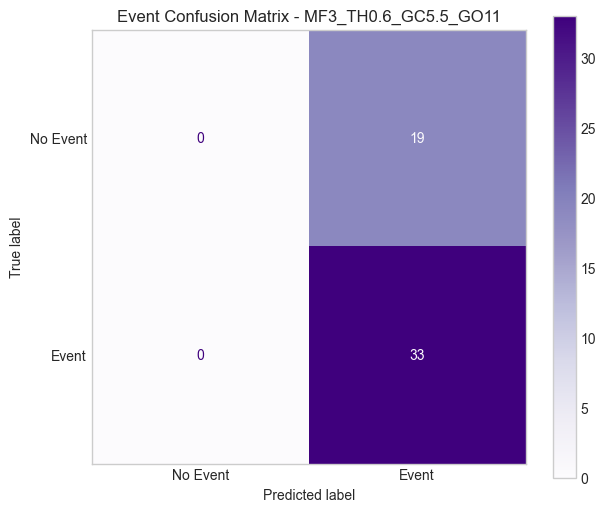

In [10]:
# ── CELL 10  Assess ───────────────────────────────────────────────────────────
importlib.reload(tp)

tp.assess_performance(
    preds_dir  = predictions_dir,
    val_dir    = VAL_DIR,
    ppc        = ppc,
    prefixes   = TRAIN_PREFIXES,
    sources    = sources,
    report_path= report_path,
    plots      = plot_path,
    dwell_tags = ["wonderful"],
    rf_assess  = True,
    val_keys   = val_keys,    # ← restricts evaluation to val-only larvae
    train_keys = train_keys,  # ← raises error if any train larva leaked in
)

In [15]:
# ── CELL 11  Plot grid ────────────────────────────────────────────────────────
importlib.reload(tp)

tp.plot_source_grid(predictions_dir, "GA2", predictions_dir, ppc, cols=10,rows=40)

c:\Users\corna\honours\fresh1\hp_2\notebooks\parquet_pipeline\tp_export.py:444: DtypeWarning: Columns (0: behavior, 1: tags) have mixed types. Specify dtype option on import or set low_memory=False.
  results   = pd.read_csv(pred_path).copy()


  Plotting 400 tracks for source GA2 in a 40×10 grid…

  Saved: C:\Users\corna\honours\fresh1\hp_2\data_intermediate\exported_models\RUN_feature_registry_test_20260609_113618_train-GA1-GA3-GA2-EA-H2O\predictions\grid_GA2.png


---
## Utilities

Run any of these stand-alone at any time.

In [ ]:
# Browse all cached feature columns
import feature_store as fs
df_cols = fs.list_cached_features(MASTER_CACHE_DIR)
print(f"{len(df_cols)} feature columns in cache")
df_cols

In [ ]:
# Health-check: are all ctx sources cached?
import feature_store as fs
fs.check_cache_health(MASTER_CACHE_DIR, ctx=ctx)

In [ ]:
# Load raw cached features for one source (for manual inspection / plotting)
import feature_store as fs
df_h2o = fs.load_source_features(MASTER_CACHE_DIR, "H2O")
print(df_h2o.shape)
df_h2o.head()

In [ ]:
# Load a saved FeatureSetConfig from a previous run
from feature_store import FeatureSetConfig
old_fsc = FeatureSetConfig.load(BASE_OUT_DIR / "RUN_xxx" / "feature_set_config.json")
print(old_fsc.summary())